# 03. Classification: Healthy vs. Faulty engines

Binary classification. An engine is *faulty* when its remaining TTF is
<= 30 cycles. Two models compared:
1. **Logistic regression** with a threshold tuned for recall >= 0.95
2. **KNN** with K chosen by 10-fold engine-level CV and a Youden-J threshold

Recall is prioritised because missing a real failure is much more costly than
a false alarm in aircraft maintenance.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from src.preprocessing import (
    load_data, smooth_sensors_per_engine,
    fit_zscore, apply_zscore, last_cycle_per_engine,
    FEATURE_COLS, FAULT_THRESHOLD,
)
from src.classification import (
    tune_logistic_threshold, fit_logistic,
    tune_knn_k, youden_threshold,
)
from src.evaluation import (
    classification_metrics, plot_roc, plot_confusion,
)

train, test, y_true_test = load_data('../data')

## Preprocessing

In [2]:
train_s = smooth_sensors_per_engine(train)
test_s  = smooth_sensors_per_engine(test)

X_train = train_s[FEATURE_COLS]
y_train = (train_s['ttf'] <= FAULT_THRESHOLD).astype(int).values
engine_ids_train = train_s['id'].values

X_test_last = last_cycle_per_engine(test_s)[FEATURE_COLS]
y_test = (y_true_test <= FAULT_THRESHOLD).astype(int)

# Z-score normalisation using training statistics
mu, sigma = fit_zscore(X_train)
X_train_n = apply_zscore(X_train.values, mu, sigma)
X_test_n  = apply_zscore(X_test_last.values, mu, sigma)

print(f'Train faulty fraction: {y_train.mean():.3f}')
print(f'Test  faulty fraction: {y_test.mean():.3f}')

Train faulty fraction: 0.150
Test  faulty fraction: 0.250


## Logistic regression with recall-targeted threshold

In [3]:
log_threshold = tune_logistic_threshold(
    X_train_n, y_train, engine_ids_train,
    n_splits=10, target_recall=0.95,
)
print(f'Threshold (mean across 10 folds): {log_threshold:.4f}')

log_model = fit_logistic(X_train_n, y_train)
prob_log_train = log_model.predict_proba(X_train_n)[:, 1]
prob_log_test  = log_model.predict_proba(X_test_n)[:, 1]
pred_log_train = (prob_log_train >= log_threshold).astype(int)
pred_log_test  = (prob_log_test  >= log_threshold).astype(int)

Threshold (mean across 10 folds): 0.1621


## KNN with K tuned by F1

Best K = 41, CV F1 = 0.8272


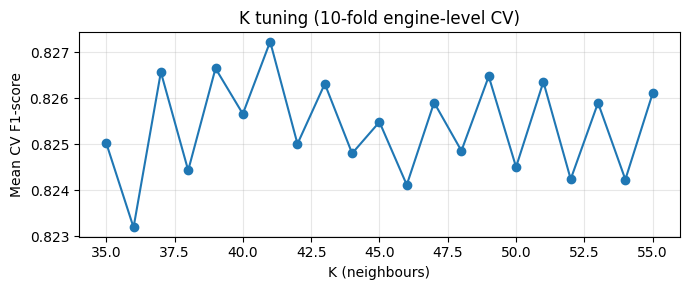

In [4]:
best_k, cv_scores = tune_knn_k(
    X_train_n, y_train, engine_ids_train,
    k_range=range(35, 56), n_splits=10,
)
print(f'Best K = {best_k}, CV F1 = {max(cv_scores):.4f}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(list(range(35, 56)), cv_scores, marker='o')
ax.set_xlabel('K (neighbours)')
ax.set_ylabel('Mean CV F1-score')
ax.set_title('K tuning (10-fold engine-level CV)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/09_knn_k_tuning.png', dpi=150)
plt.show()

In [5]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_n, y_train)

prob_knn_train = knn_model.predict_proba(X_train_n)[:, 1]
prob_knn_test  = knn_model.predict_proba(X_test_n)[:, 1]

knn_threshold = youden_threshold(y_train, prob_knn_train)
print(f'KNN threshold (Youden J): {knn_threshold:.4f}')

pred_knn_train = (prob_knn_train >= knn_threshold).astype(int)
pred_knn_test  = (prob_knn_test  >= knn_threshold).astype(int)

KNN threshold (Youden J): 0.1463


## Performance comparison

In [6]:
results = pd.DataFrame({
    'Logistic (train)': classification_metrics(y_train, pred_log_train, prob_log_train),
    'Logistic (test)' : classification_metrics(y_test,  pred_log_test,  prob_log_test),
    'KNN (train)'     : classification_metrics(y_train, pred_knn_train, prob_knn_train),
    'KNN (test)'      : classification_metrics(y_test,  pred_knn_test,  prob_knn_test),
}).round(4)
results

,Logistic (train),Logistic (test),KNN (train),KNN (test)
Accuracy,0.9279,0.9100,0.9207,0.9200
Precision,0.6939,0.8077,0.6593,0.7576
Recall,0.9303,0.8400,0.9774,1.0000
F1,0.7949,0.8235,0.7874,0.8621
AUC,0.9827,0.9600,0.9885,0.9733


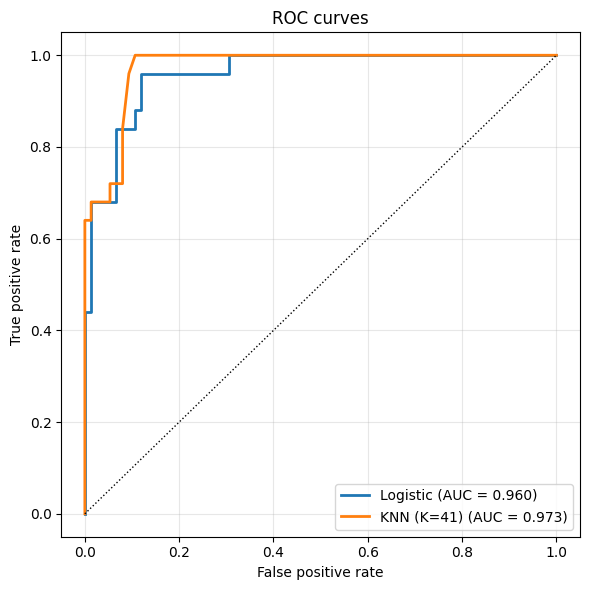

In [7]:
# ROC curves on the test set
fig, ax = plt.subplots(figsize=(6, 6))
plot_roc({
    'Logistic': (y_test, prob_log_test),
    f'KNN (K={best_k})': (y_test, prob_knn_test),
}, ax=ax)
plt.tight_layout()
plt.savefig('../figures/10_roc_curves.png', dpi=150)
plt.show()

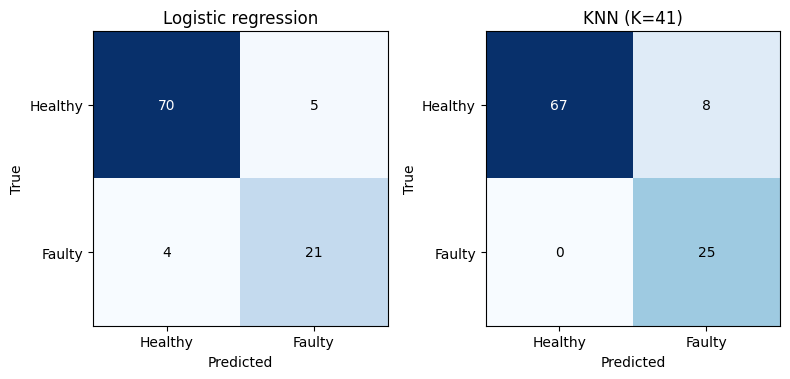

In [8]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_confusion(y_test, pred_log_test, 'Logistic regression', ax=axes[0])
plot_confusion(y_test, pred_knn_test, f'KNN (K={best_k})',   ax=axes[1])
plt.tight_layout()
plt.savefig('../figures/11_confusion_matrices.png', dpi=150)
plt.show()

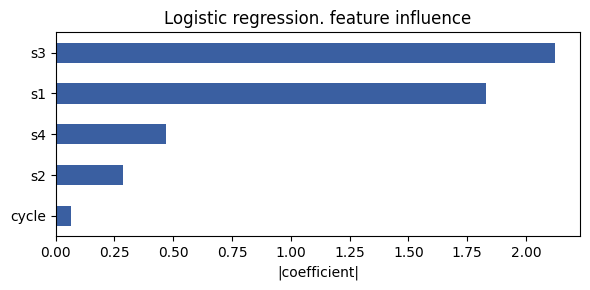

In [9]:
# Logistic coefficients (feature influence)
coefs = pd.Series(np.abs(log_model.coef_[0]), index=FEATURE_COLS)
fig, ax = plt.subplots(figsize=(6, 3))
coefs.sort_values().plot.barh(ax=ax, color='#3a5fa1')
ax.set_xlabel('|coefficient|')
ax.set_title('Logistic regression. feature influence')
plt.tight_layout()
plt.savefig('../figures/12_logistic_coefficients.png', dpi=150)
plt.show()

## Conclusion

KNN achieves slightly higher recall and F1-score than logistic regression
without sacrificing precision substantially. Both models exceed AUC = 0.95 on
the test set, but the recall-driven threshold tuning is what keeps undetected
failures low, which is a non-trivial requirement in aviation maintenance.

**Limitations and future work**
- The training set covers 100 engines under similar operating conditions; a
  larger fleet would help generalisation.
- Both models look at a single cycle in isolation. Sequence models such as
  LSTM or 1D-CNN could exploit the time-series nature of the sensor signals.
- Class imbalance was handled with thresholding; cost-sensitive losses
  (`class_weight='balanced'` or focal loss) are an alternative.